# 17 — Deux journaux qui enregistrent le rang servi

Le [notebook 16](16_exploration_mind.ipynb) s'est terminé sur une exigence plutôt que sur un
résultat : il faut un jeu de données qui **enregistre le rang d'affichage**, faute de quoi
l'exposition n'est pas identifiable et l'évaluation contrefactuelle d'un réordonnancement est
vide par construction.

Ce notebook va chercher ces journaux et leur applique les mêmes contrôles. Deux répondent, et
pas à la même exigence.

**[Baidu-ULTR](https://arxiv.org/abs/2207.03051)** (Zou et al., 2022) enregistre le rang
d'affichage de chaque document dans une page de résultats, avec le clic et la session — la
structure exacte que MIND avait détruite.

**L'[Open Bandit Dataset](https://arxiv.org/abs/2008.07146)** (Saito et al., 2020) publie en
plus la **propension vraie** de chaque affichage, et contient un seau où la politique de
service est **uniformément aléatoire**. C'est le seul jeu où la condition la plus coûteuse des
estimateurs contrefactuels — connaître $\pi_0$ au lieu de la modéliser — est satisfaite
littéralement.

**Ce que ce notebook établit :**

* Baidu-ULTR **passe le contrôle positif** que MIND avait échoué : $z = -206$, du bon côté —
  les clics se concentrent en haut, comme un biais de position l'exige ;
* la sévérité y vaut $\hat\eta = 1{,}10 \pm 0{,}09$ par effets fixes de contenu, contre 1,49
  par ajustement agrégé : l'écart est le **confondant de qualité**, la plateforme plaçant les
  meilleurs documents en tête ;
* sur l'Open Bandit Dataset, l'effet de position est **dix fois plus faible** — un bandeau de
  trois vignettes horizontales n'est pas une page de résultats verticale, et $\eta$ est une
  propriété de la **surface**, pas une constante ;
* l'estimation IPS de la valeur d'une politique **non déployée** tombe à 2,5 % de la valeur
  mesurée directement, là où l'estimation naïve se trompe de 32 % — mais la **taille
  d'échantillon effective** vaut 1 513 pour 4 millions d'impressions, et c'est le chiffre qui
  interdit de crier victoire.

Les journaux bruts pèsent 3,1 Go et portent deux licences distinctes : ils ne sont pas
versionnés. Ce notebook lit le **condensé** `data/exposure_digest.npz`, qui rend à l'identique
tous les chiffres ci-dessous — un test le vérifie — et se reconstruit par
`scripts/fetch_exposure.py` puis `scripts/build_exposure_digest.py`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from ide.exposure import bucket_from_digest, load_digest, obd_click_rates, off_policy_check
from ide.logs import click_rate_by_rank, exchangeability_test, naive_severity_fit
from ide.mind import load_digest as load_mind_digest
from ide.offpolicy import estimate_position_bias
from ide.plotting import PALETTE, save_figure, use_project_style

use_project_style()

digest = load_digest()
baidu = digest.impressions("baidu")
lengths = baidu.feed_lengths

print(f"Baidu-ULTR : {baidu.feed_count} sessions, {baidu.served} documents servis, "
      f"taux de clic {baidu.click_rate:.4f}")
print(f"  longueur de session : médiane {np.median(lengths):.0f}, min {lengths.min()}, "
      f"max {lengths.max()}")
print(f"  rang servi : de {baidu.ranks.min()} à {baidu.ranks.max()}")
print(f"  source (SHA-256) : {digest.sources['baidu']}")

Baidu-ULTR : 64200 sessions, 524164 documents servis, taux de clic 0.0843
  longueur de session : médiane 8, min 5, max 19
  rang servi : de 1 à 20
  source (SHA-256) : 3ffee6ef4c644e30168eed8c6533a4346c604a63b5bd89c4ef85fe075726066b


## 1. Le contrôle positif que MIND avait échoué

Le test d'échangeabilité intra-fil demande, à session donnée, si les clics sont répartis
indépendamment de la position enregistrée. Sur MIND il ne détectait rien. Il faut vérifier
qu'il détecte quelque chose là où il y a quelque chose — sinon son verdict sur MIND ne
distinguerait pas un jeu mélangé d'un test aveugle.

In [2]:
mind = load_mind_digest().impressions("train")

print(f"{'journal':16s} {'fils utiles':>12s} {'z':>12s} {'p':>10s}   verdict")
print("-" * 72)
verdicts = {}
for name, impressions in (("MIND", mind), ("Baidu-ULTR", baidu)):
    verdict = exchangeability_test(impressions)
    verdicts[name] = verdict
    reading = ("ordre indiscernable d'un mélange" if verdict.exchangeable
               else "l'ordre porte le placement")
    print(f"{name:16s} {verdict.feeds_used:12d} {verdict.deviation:12.2f} "
          f"{verdict.p_value:10.3g}   {reading}")

print("\nLe signe compte autant que l'ampleur : un biais de position concentre les clics en")
print("haut, donc la somme des rangs cliqués tombe SOUS son espérance. Un rejet du côté")
print("positif signalerait une erreur, pas une découverte.")

journal           fils utiles            z          p   verdict
------------------------------------------------------------------------


MIND                   156965         0.12      0.908   ordre indiscernable d'un mélange
Baidu-ULTR              29916      -205.72          0   l'ordre porte le placement

Le signe compte autant que l'ampleur : un biais de position concentre les clics en
haut, donc la somme des rangs cliqués tombe SOUS son espérance. Un rejet du côté
positif signalerait une erreur, pas une découverte.


## 2. La sévérité, mesurée trois fois

Trois estimations du même jeu, cette fois sans contradiction — mais pas identiques, et l'écart
se lit.

In [3]:
items, ranks, clicks = digest.rows("baidu")
fixed_effects = estimate_position_bias(items, ranks, clicks, minimum_impressions=5)
aggregate = naive_severity_fit(baidu, maximum_rank=10)
at_ten = naive_severity_fit(baidu, maximum_rank=10, feed_length=10)

baidu_rates = click_rate_by_rank(baidu, maximum_rank=12)
print(f"{'rang':>5s} {'taux de clic':>13s}")
print("-" * 20)
for position in (1, 2, 3, 5, 8, 10, 12):
    print(f"{position:5d} {baidu_rates[position - 1]:13.5f}")

print(f"\najustement agrégé (rangs 1-10)          : η = {aggregate:.3f}")
print(f"à longueur de session fixée (10 documents) : η = {at_ten:.3f}")
print(f"effets fixes de document                   : η = {fixed_effects.severity:.3f} "
      f"± {fixed_effects.standard_error:.3f}")
print(f"   documents portant l'estimation : {fixed_effects.items_with_variation}")

 rang  taux de clic
--------------------
    1       0.34004
    2       0.17235
    3       0.08814
    5       0.04275
    8       0.01931
   10       0.00969
   12       0.00405

ajustement agrégé (rangs 1-10)          : η = 1.494
à longueur de session fixée (10 documents) : η = 1.144
effets fixes de document                   : η = 1.099 ± 0.089
   documents portant l'estimation : 55


### Pourquoi l'ajustement agrégé surestime

Sur MIND, l'écart entre l'ajustement agrégé et les effets fixes venait de la **composition des
longueurs**. Ici il vient d'autre chose, et de plus attendu : la plateforme place les
**meilleurs documents en tête**. Une partie de la décroissance du taux de clic est donc de la
qualité, pas de l'exposition — et c'est exactement ce que les effets fixes de document
éliminent, en ne comparant un document qu'à lui-même.

Le contrôle par longueur de session ne suffit pas ici : il retire le mélange des longueurs, pas
la qualité.

!!! warning "Et la couverture est mince"
    Les effets fixes ne reposent que sur les documents vus à **plusieurs rangs distincts**. Sur
    une page de résultats de recherche, une même URL réapparaît rarement : la couverture est
    bien plus faible que le nombre de lignes ne le laisse croire.

In [4]:
coverage = digest.coverage("baidu")
print(f"documents distincts                        : {coverage.items}")
print(f"documents au-dessus du seuil d'impressions : {coverage.items_above_threshold}")
print(f"documents vus à plusieurs rangs            : {coverage.items_with_variation}")
print(f"rangs distincts par document (médiane)     : {coverage.median_distinct_ranks:.0f}")
print("\nCinquante-cinq documents portent l'estimation, sur près d'un demi-million. Le")
print("chiffre est identifié — l'erreur type le dit — mais la marge est celle-là, pas celle")
print("qu'un demi-million de lignes suggérerait.")

documents distincts                        : 444709
documents au-dessus du seuil d'impressions : 335
documents vus à plusieurs rangs            : 55
rangs distincts par document (médiane)     : 1

Cinquante-cinq documents portent l'estimation, sur près d'un demi-million. Le
chiffre est identifié — l'erreur type le dit — mais la marge est celle-là, pas celle
qu'un demi-million de lignes suggérerait.


## 3. L'Open Bandit Dataset : la position mesurée sans modèle

Le seau **aléatoire** de l'Open Bandit Dataset affecte les contenus aux positions au hasard.
L'écart de taux de clic entre positions y est donc un effet **causal** de la position, sans
qu'aucun modèle d'examen n'ait à être posé. C'est la mesure la plus propre qu'on puisse faire
de $\eta$ — et elle porte sur une surface toute différente : trois vignettes **horizontales**,
de gauche à droite.

In [5]:
print(f"{'seau':16s} {'position':>9s} {'impressions':>12s} {'clics':>8s} {'taux':>9s} {'±':>8s}")
print("-" * 68)
obd_rates = {}
for name in ("obd_random_all", "obd_random_men"):
    bucket = bucket_from_digest(digest, name)
    obd_rates[name] = obd_click_rates(bucket)
    for position, (exposures, successes, rate, error) in sorted(obd_rates[name].items()):
        label = name if position == 1 else ""
        print(f"{label:16s} {position:9d} {exposures:12d} {successes:8d} {rate:9.5f} "
              f"{error:8.5f}")

for name, bucket_rates in obd_rates.items():
    positions = np.array(sorted(bucket_rates))
    values = np.array([bucket_rates[p][2] for p in positions])
    slope = np.polyfit(np.log(positions), np.log(values), 1)[0]
    print(f"\n{name} : η ajusté sur trois positions = {-slope:.3f}")

first, last = obd_rates["obd_random_all"][1], obd_rates["obd_random_all"][3]
gap = first[2] - last[2]
print(f"\nCampagne « all » : écart première/dernière vignette = {gap:.5f}, "
      f"pour des erreurs types de {first[3]:.5f}.")
print("L'effet existe et va dans le bon sens ; à cette taille il n'est pas concluant")
print("vignette à vignette.")

seau              position  impressions    clics      taux        ±
--------------------------------------------------------------------
obd_random_all           1       458005     1622   0.00354  0.00009
                         2       458158     1590   0.00347  0.00009
                         3       458164     1556   0.00340  0.00009
obd_random_men           1       150936      812   0.00538  0.00019
                         2       151008      792   0.00524  0.00019
                         3       151005      717   0.00475  0.00018

obd_random_all : η ajusté sur trois positions = 0.037

obd_random_men : η ajusté sur trois positions = 0.105

Campagne « all » : écart première/dernière vignette = 0.00015, pour des erreurs types de 0.00009.
L'effet existe et va dans le bon sens ; à cette taille il n'est pas concluant
vignette à vignette.


!!! danger "$\eta$ n'est pas une constante, c'est une propriété de la surface"
    Une page de résultats verticale décroît en $R^{-1{,}1}$ ; un bandeau de trois vignettes
    horizontales décroît en $R^{-0{,}04}$ à $R^{-0{,}11}$ selon la campagne. Un ordre de
    grandeur sépare les deux.

    Le [notebook 15](15_rang_adverse_et_severite.ipynb) avait chiffré ce que coûte un $\eta$
    posé de travers : jusqu'à +179 % sur le chiffre publié. Transporter la valeur d'une page de
    résultats vers un bandeau — ou l'inverse — est précisément une erreur de cette taille.

## 4. La confrontation : une estimation contrefactuelle jugée contre la vérité

L'Open Bandit Dataset contient deux seaux servis **en parallèle** par deux politiques
différentes. On peut donc faire ce qu'aucun autre jeu de ce dépôt ne permet : estimer la valeur
de la politique uniforme **à partir des seules données d'une autre politique**, puis la
comparer à sa valeur mesurée directement là où elle a réellement servi.

In [6]:
check = off_policy_check(
    bucket_from_digest(digest, "obd_random_men"),
    bucket_from_digest(digest, "obd_bts_men"),
)

print(f"vérité terrain (politique uniforme, mesurée) : {check.truth:.6f} ± {check.truth_error:.6f}")
print(f"journal d'enregistrement (Bernoulli TS)      : {check.logged_size} impressions\n")
print(f"{'estimateur':28s} {'valeur':>10s} {'écart à la vérité':>19s}")
print("-" * 60)
estimates = [("naïf (taux de clic observé)", check.naive),
             ("IPS", check.importance_sampling),
             ("SNIPS", check.self_normalised)]
estimates += [(f"IPS plafonné à {cap:.0f}", value) for cap, value in check.clipped.items()]
for label, value in estimates:
    print(f"{label:28s} {value:10.6f} {100 * check.relative_error(value):18.1f} %")

print(f"\ntaille d'échantillon effective : {check.effective_size:.0f} sur {check.logged_size} "
      f"({100 * check.effective_share:.3f} %)")

vérité terrain (politique uniforme, mesurée) : 0.005124 ± 0.000106
journal d'enregistrement (Bernoulli TS)      : 4077727 impressions

estimateur                       valeur   écart à la vérité
------------------------------------------------------------
naïf (taux de clic observé)    0.006743               31.6 %
IPS                            0.005253                2.5 %
SNIPS                          0.004768               -7.0 %
IPS plafonné à 10              0.004473              -12.7 %
IPS plafonné à 100             0.005238                2.2 %
IPS plafonné à 1000            0.005253                2.5 %

taille d'échantillon effective : 1513 sur 4077727 (0.037 %)


### Ce que ce tableau dit, et ce qu'il ne dit pas

**Il dit que la correction fonctionne.** L'estimation naïve — le taux de clic observé sous la
politique d'enregistrement, c'est-à-dire ce que mesure un *replay* — se trompe de **+32 %**.
L'IPS, qui repondère chaque observation par l'inverse de sa propension, tombe à **2,5 %** de la
valeur vraie. C'est la première fois dans ce dépôt qu'un estimateur contrefactuel est jugé
contre la grandeur qu'il prétend estimer, et non contre une simulation.

**Il ne dit pas que l'estimation est précise.** La taille d'échantillon effective vaut **1 513**
pour 4 077 727 impressions, soit 0,04 %. L'estimation sans biais repose sur l'équivalent de
mille cinq cents observations : à un taux de clic de 0,005, cela laisse une marge de l'ordre de
la moitié du chiffre. Que l'écart tombe à 2,5 % tient donc autant à la chance qu'à la méthode.

C'est exactement le diagnostic que `ide.offpolicy` impose de publier à côté du chiffre, et
voici le cas réel qui montre pourquoi : sans lui, on croirait tenir une mesure sur quatre
millions de lignes.

**Et le plafonnement n'est pas gratuit.** Plafonner les poids à 10 ramène l'estimation à
$-12{,}7$ % : le biais échangé contre de la variance est du même ordre que l'erreur qu'on
cherchait à corriger. Le plafond doit être publié avec le chiffre, faute de quoi le choix du
plafond suffit à déplacer le résultat.

## 5. La figure

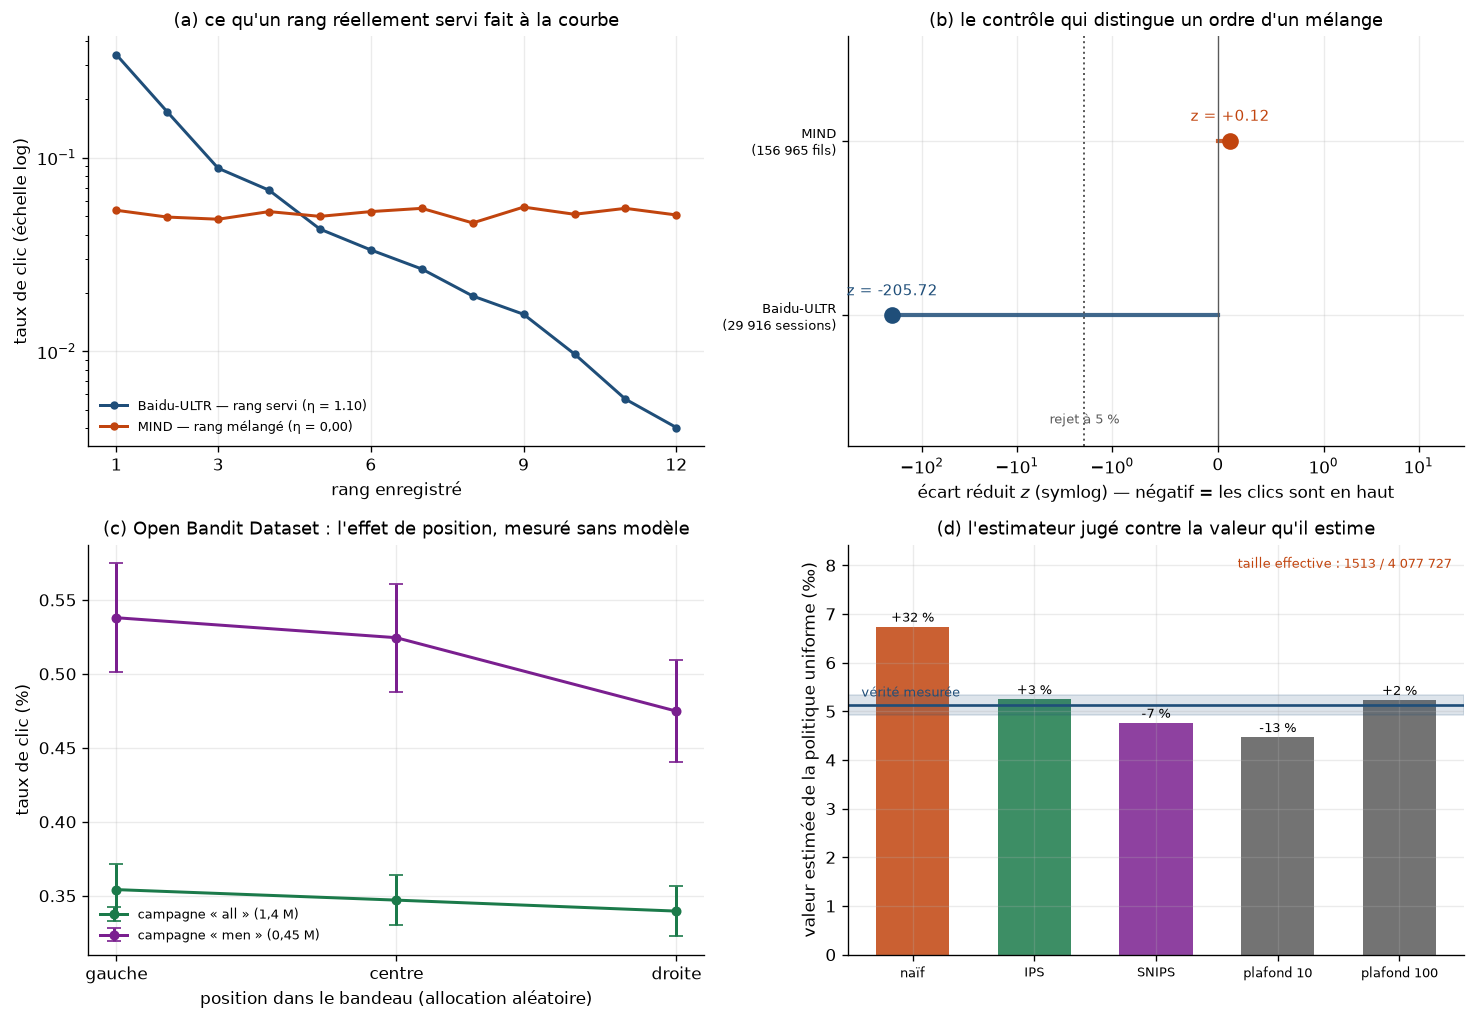

In [7]:
figure, axes = plt.subplots(2, 2, figsize=(12.4, 8.6))

# (a) le rang enregistré fait ou ne fait pas la courbe
ax = axes[0, 0]
positions = np.arange(1, 13)
mind_rates = click_rate_by_rank(mind, maximum_rank=12, feed_length=30)
ax.plot(positions, baidu_rates[:12], "o-", color=PALETTE["order"], markersize=4,
        label=f"Baidu-ULTR — rang servi (η = {fixed_effects.severity:.2f})")
ax.plot(positions, mind_rates, "o-", color=PALETTE["disorder"], markersize=4,
        label="MIND — rang mélangé (η = 0,00)")
ax.set_yscale("log")
ax.set_xlabel("rang enregistré")
ax.set_ylabel("taux de clic (échelle log)")
ax.set_title("(a) ce qu'un rang réellement servi fait à la courbe")
ax.set_xticks([1, 3, 6, 9, 12])
ax.legend(loc="lower left", fontsize=8)

# (b) le test d'échangeabilité sur les deux journaux
ax = axes[0, 1]
names = ["MIND\n(156 965 fils)", "Baidu-ULTR\n(29 916 sessions)"]
deviations = [verdicts["MIND"].deviation, verdicts["Baidu-ULTR"].deviation]
colours = [PALETTE["disorder"], PALETTE["order"]]
ax.set_xscale("symlog", linthresh=1)
for index, (value, colour) in enumerate(zip(deviations, colours, strict=True)):
    ax.plot([0, value], [index, index], color=colour, linewidth=2.5, alpha=0.85)
    ax.plot([value], [index], "o", color=colour, markersize=9)
    ax.annotate(f"z = {value:+.2f}", xy=(value, index), xytext=(0, 12),
                textcoords="offset points", ha="center", fontsize=9, color=colour)
ax.axvline(-1.96, color=PALETTE["neutral"], linestyle=":", linewidth=1.2)
ax.text(-1.96, 1.62, "rejet à 5 %", fontsize=8, color=PALETTE["neutral"], ha="center")
ax.axvline(0.0, color=PALETTE["neutral"], linewidth=0.8)
ax.set_yticks([0, 1])
ax.set_yticklabels(names, fontsize=8)
ax.set_ylim(1.75, -0.6)
ax.set_xlim(-600, 30)
ax.set_xlabel("écart réduit $z$ (symlog) — négatif = les clics sont en haut")
ax.set_title("(b) le contrôle qui distingue un ordre d'un mélange")

# (c) trois vignettes horizontales : l'effet est ténu
ax = axes[1, 0]
for name, colour, label in (("obd_random_all", PALETTE["remedy"], "campagne « all » (1,4 M)"),
                            ("obd_random_men", PALETTE["field"], "campagne « men » (0,45 M)")):
    slots = np.array(sorted(obd_rates[name]))
    values = np.array([obd_rates[name][s][2] for s in slots])
    errors = np.array([obd_rates[name][s][3] for s in slots])
    ax.errorbar(slots, 100 * values, yerr=100 * 1.96 * errors, fmt="o-", color=colour,
                markersize=5, capsize=4, label=label)
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(["gauche", "centre", "droite"])
ax.set_xlabel("position dans le bandeau (allocation aléatoire)")
ax.set_ylabel("taux de clic (%)")
ax.set_title("(c) Open Bandit Dataset : l'effet de position, mesuré sans modèle")
ax.legend(loc="lower left", fontsize=8)

# (d) la confrontation
ax = axes[1, 1]
labels = ["naïf", "IPS", "SNIPS", "plafond 10", "plafond 100"]
values = [check.naive, check.importance_sampling, check.self_normalised,
          check.clipped[10.0], check.clipped[100.0]]
bar_colours = [PALETTE["disorder"], PALETTE["remedy"], PALETTE["field"],
               PALETTE["neutral"], PALETTE["neutral"]]
ax.bar(labels, [1000 * value for value in values], color=bar_colours, alpha=0.85, width=0.6)
ax.axhline(1000 * check.truth, color=PALETTE["order"], linewidth=1.6)
ax.axhspan(1000 * (check.truth - 1.96 * check.truth_error),
           1000 * (check.truth + 1.96 * check.truth_error),
           color=PALETTE["order"], alpha=0.15)
ax.text(-0.42, 1000 * check.truth + 0.18, "vérité mesurée", fontsize=8,
        color=PALETTE["order"], ha="left")
for index, value in enumerate(values):
    ax.text(index, 1000 * value + 0.1, f"{100 * check.relative_error(value):+.0f} %",
            ha="center", fontsize=8)
ax.set_ylabel("valeur estimée de la politique uniforme (‰)")
ax.set_title("(d) l'estimateur jugé contre la valeur qu'il estime")
ax.tick_params(axis="x", labelsize=8)
ax.set_ylim(0, 1000 * max(values) * 1.25)
ax.text(0.98, 0.97, f"taille effective : {check.effective_size:.0f} / {check.logged_size:,}"
        .replace(",", " "), transform=ax.transAxes, fontsize=8, color=PALETTE["disorder"],
        ha="right", va="top")

save_figure(figure, "fig17_rang_servi")
plt.show()

## 6. Ce que ces deux journaux règlent, et ce qu'ils ne règlent pas

**Réglé : le critère de choix d'un jeu de données.** Il ne s'agit ni de la taille ni de la
présence d'étiquettes éditoriales, mais de l'enregistrement du rang servi — et cela se
**vérifie** en une ligne, par le test d'échangeabilité, avant toute mesure.

**Réglé : la sévérité n'a plus à être posée.** Elle vaut 1,10 ± 0,09 sur une page de résultats
de recherche et un dixième de cela sur un bandeau de trois vignettes. Les deux chiffres sont
mesurés ; ce qui reste interdit est de transporter l'un vers l'autre surface.

**Réglé : les estimateurs contrefactuels tiennent devant une vérité terrain** — à 2,5 %, quand
le naïf se trompe de 32 %. Avec la réserve, chiffrée, que leur précision effective est bien
moindre que le nombre de lignes ne le suggère.

**Non réglé : aucun de ces jeux ne permet d'évaluer l'ADE.** Il y faudrait le rang servi **et**
une étiquette de point de vue interprétable. MIND porte des catégories éditoriales mais pas le
rang. Baidu-ULTR porte le rang mais ses documents n'ont aucune étiquette exploitable — requêtes
et titres y sont des identifiants numériques. L'Open Bandit Dataset porte le rang, la propension
et trois attributs catégoriels par article — mais **anonymisés** : on peut calculer une
diversité sur des hachages, on ne peut pas déclarer le catalogue de référence qu'exige l'IDE, et
une diversité sur des catégories dont personne ne sait ce qu'elles désignent est exactement le
genre de mesure que ce dépôt refuse.

C'est donc le troisième résultat négatif de cette série, et il faut le dire aussi nettement que
les deux autres : **le jeu de données qui permettrait l'évaluation annoncée n'existe pas
publiquement.** Ce qui reste possible se dit en trois lignes, et c'est la [feuille de
route](../docs/feuille-de-route.md) qui en hérite :

1. mesurer sur MIND ce qui ne dépend pas de l'exposition, en le disant ;
2. mesurer sur Baidu-ULTR et l'Open Bandit Dataset ce qui ne dépend pas des points de vue ;
3. pour le reste, demander la donnée — ce qui, sous l'article 40 du DSA, est une démarche
   prévue, et non un vœu.